# Basal vs Hillock 

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variance

In [5]:
rsc.tl.rank_genes_groups(
    comb,
    groupby="ann_lvl_3_refined",
    groups=["Hillock"],
    reference="BC",
    method="wilcoxon",
    use_raw=True,
    pts=True,
)

In [7]:
de = sc.get.rank_genes_groups_df(
    comb, 
    group='Hillock',
).set_index('names')

de_up = sc.get.rank_genes_groups_df(
    comb, 
    group='Hillock',
    pval_cutoff=0.05,
    log2fc_min=1
)

de_down = sc.get.rank_genes_groups_df(
    comb, 
    group='Hillock',
    pval_cutoff=0.05,
    log2fc_max=-1
)

In [47]:
de.head()

,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
names,,,,,
KRT6A,55.891342,6.364583,0.0,0.0,0.812668
S100A2,54.894814,5.865695,0.0,0.0,0.837896
S100A8,49.326626,7.419495,0.0,0.0,0.696726
S100A14,42.927147,4.857395,0.0,0.0,0.663983
S100A9,39.492512,4.874134,0.0,0.0,0.623725


In [9]:
import decoupler as dc

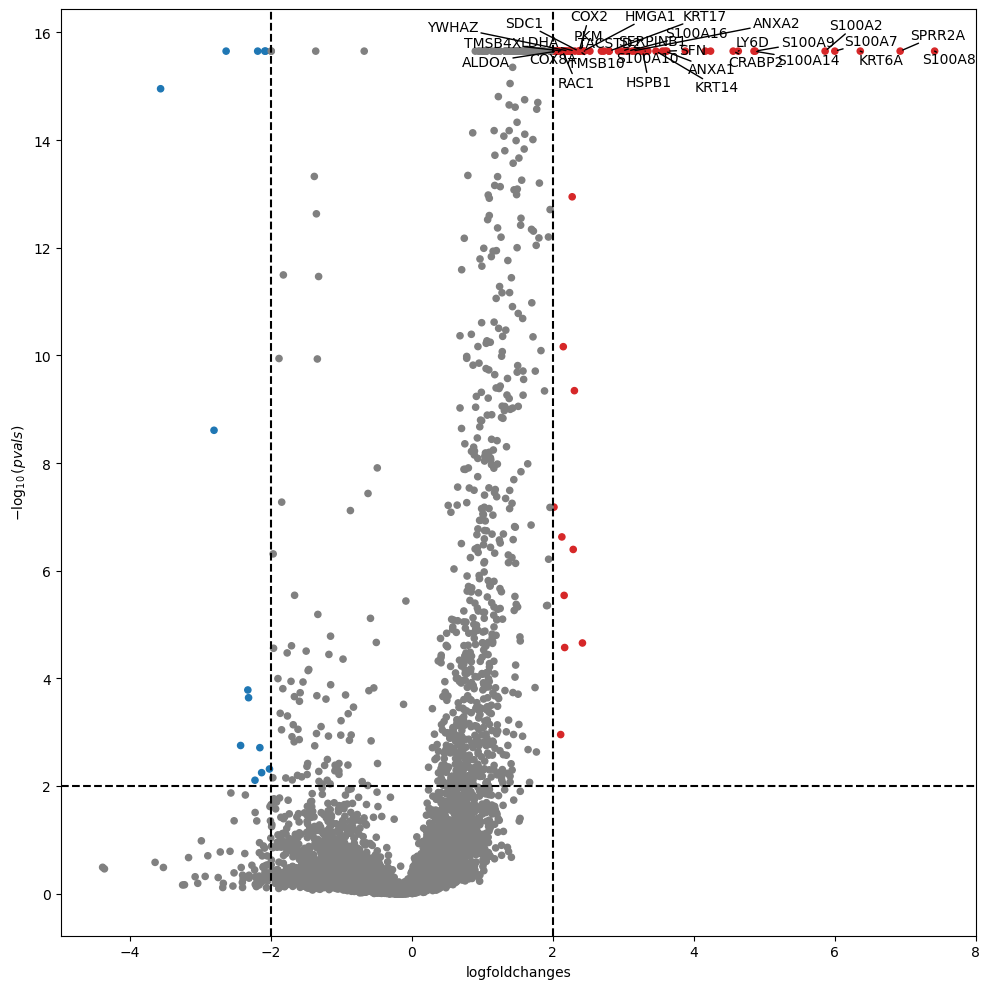

In [12]:
dc.pl.volcano(
    data=de,
    x="logfoldchanges",
    y="pvals",
    thr_stat=2,
    thr_sign=0.01,
    top=30,
    figsize=(10, 10),
)

In [55]:
de_up_list = de_up['names'].tolist()
len(de_up_list)

427

# ORA 

In [40]:
# go bp 

import decoupler as dc
import numpy as np
from statsmodels.stats.multitest import multipletests

# Retrieve MSigDB
msigdb = dc.op.resource(
    name="MSigDB",
    organism="human",
)

# Keep GO Biological Process
go_bp = (
    msigdb
    .query("collection == 'go_biological_process'")
    [["geneset", "genesymbol"]]
    .drop_duplicates()
    .rename(columns={
        "geneset": "source",
        "genesymbol": "target",
    })
)

go_bp.head()

,source,target
,,
15,GOBP_IMMUNE_RESPONSE_REGULATING_SIGNALING_PATHWAY,A1BG
53,GOBP_REGULATION_OF_IMMUNE_SYSTEM_PROCESS,A1BG
54,GOBP_REGULATION_OF_IMMUNE_RESPONSE,A1BG
85,GOBP_NUCLEAR_TRANSCRIBED_MRNA_CATABOLIC_PROCESS,A1CF
96,GOBP_INTRACELLULAR_MRNA_LOCALIZATION,A1CF


In [41]:
# Gene universe
background_genes = set(comb.raw.var_names)

go_bp = go_bp[
    go_bp["target"].isin(background_genes)
].copy()

print(go_bp.shape)
print(go_bp["source"].nunique())

(347366, 2)
7477


In [44]:
go_bp["source"] = (
    go_bp["source"]
    .str.removeprefix("GOBP_")
)

go_bp.head()

,source,target
,,
15,IMMUNE_RESPONSE_REGULATING_SIGNALING_PATHWAY,A1BG
53,REGULATION_OF_IMMUNE_SYSTEM_PROCESS,A1BG
54,REGULATION_OF_IMMUNE_RESPONSE,A1BG
308,STEM_CELL_DIFFERENTIATION,A2M
309,NEGATIVE_REGULATION_OF_COMPLEMENT_ACTIVATION,A2M


In [45]:
genes_up = (
    de_up["names"]
    .dropna()
    .loc[lambda x: x.isin(background_genes)]
    .tolist()
)

genes_down = (
    de_down["names"]
    .dropna()
    .loc[lambda x: x.isin(background_genes)]
    .tolist()
)

print("UP:", len(genes_up))
print("DOWN:", len(genes_down))

UP: 427
DOWN: 70


In [46]:
ora_go_up = dc.mt.query_set(
    features=genes_up,
    net=go_bp,
    n_bg=len(background_genes),
    tmin=5,
)

ora_go_down = dc.mt.query_set(
    features=genes_down,
    net=go_bp,
    n_bg=len(background_genes),
    tmin=5,
)

In [47]:
for df in [ora_go_up, ora_go_down]:

    df["padj"] = multipletests(
        df["pval"],
        method="fdr_bh",
    )[1]

    df["minus_log10_padj"] = -np.log10(
        df["padj"].clip(lower=1e-300)
    )

In [48]:
ora_go_up_sig = (
    ora_go_up
    .query("padj < 0.05")
    .sort_values("padj")
)

ora_go_down_sig = (
    ora_go_down
    .query("padj < 0.05")
    .sort_values("padj")
)

ora_go_up_sig.head(20)

,source,stat,pval,padj,minus_log10_padj
0,KERATINIZATION,3.648167,1.455563e-11,8.730466e-08,7.058963
1,INTERMEDIATE_FILAMENT_ORGANIZATION,2.770344,5.061309e-11,1.517887e-07,6.818761
2,INTERMEDIATE_FILAMENT_BASED_PROCESS,2.258482,7.035388e-10,1.406609e-06,5.851827
3,OXIDATIVE_PHOSPHORYLATION,1.617621,1.493362e-08,2.239296e-05,4.649889
4,NUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS,1.237629,1.029267e-07,1.068003e-04,3.971427
5,AEROBIC_RESPIRATION,1.410789,1.068359e-07,1.068003e-04,3.971427
6,CELLULAR_RESPIRATION,1.281887,3.079622e-07,2.596565e-04,3.585601
7,ATP_METABOLIC_PROCESS,1.246906,3.463240e-07,2.596565e-04,3.585601
8,ELECTRON_TRANSPORT_CHAIN,1.570587,4.669032e-07,3.111651e-04,3.507009
9,EPIDERMIS_DEVELOPMENT,1.078275,6.546244e-07,3.926437e-04,3.406001


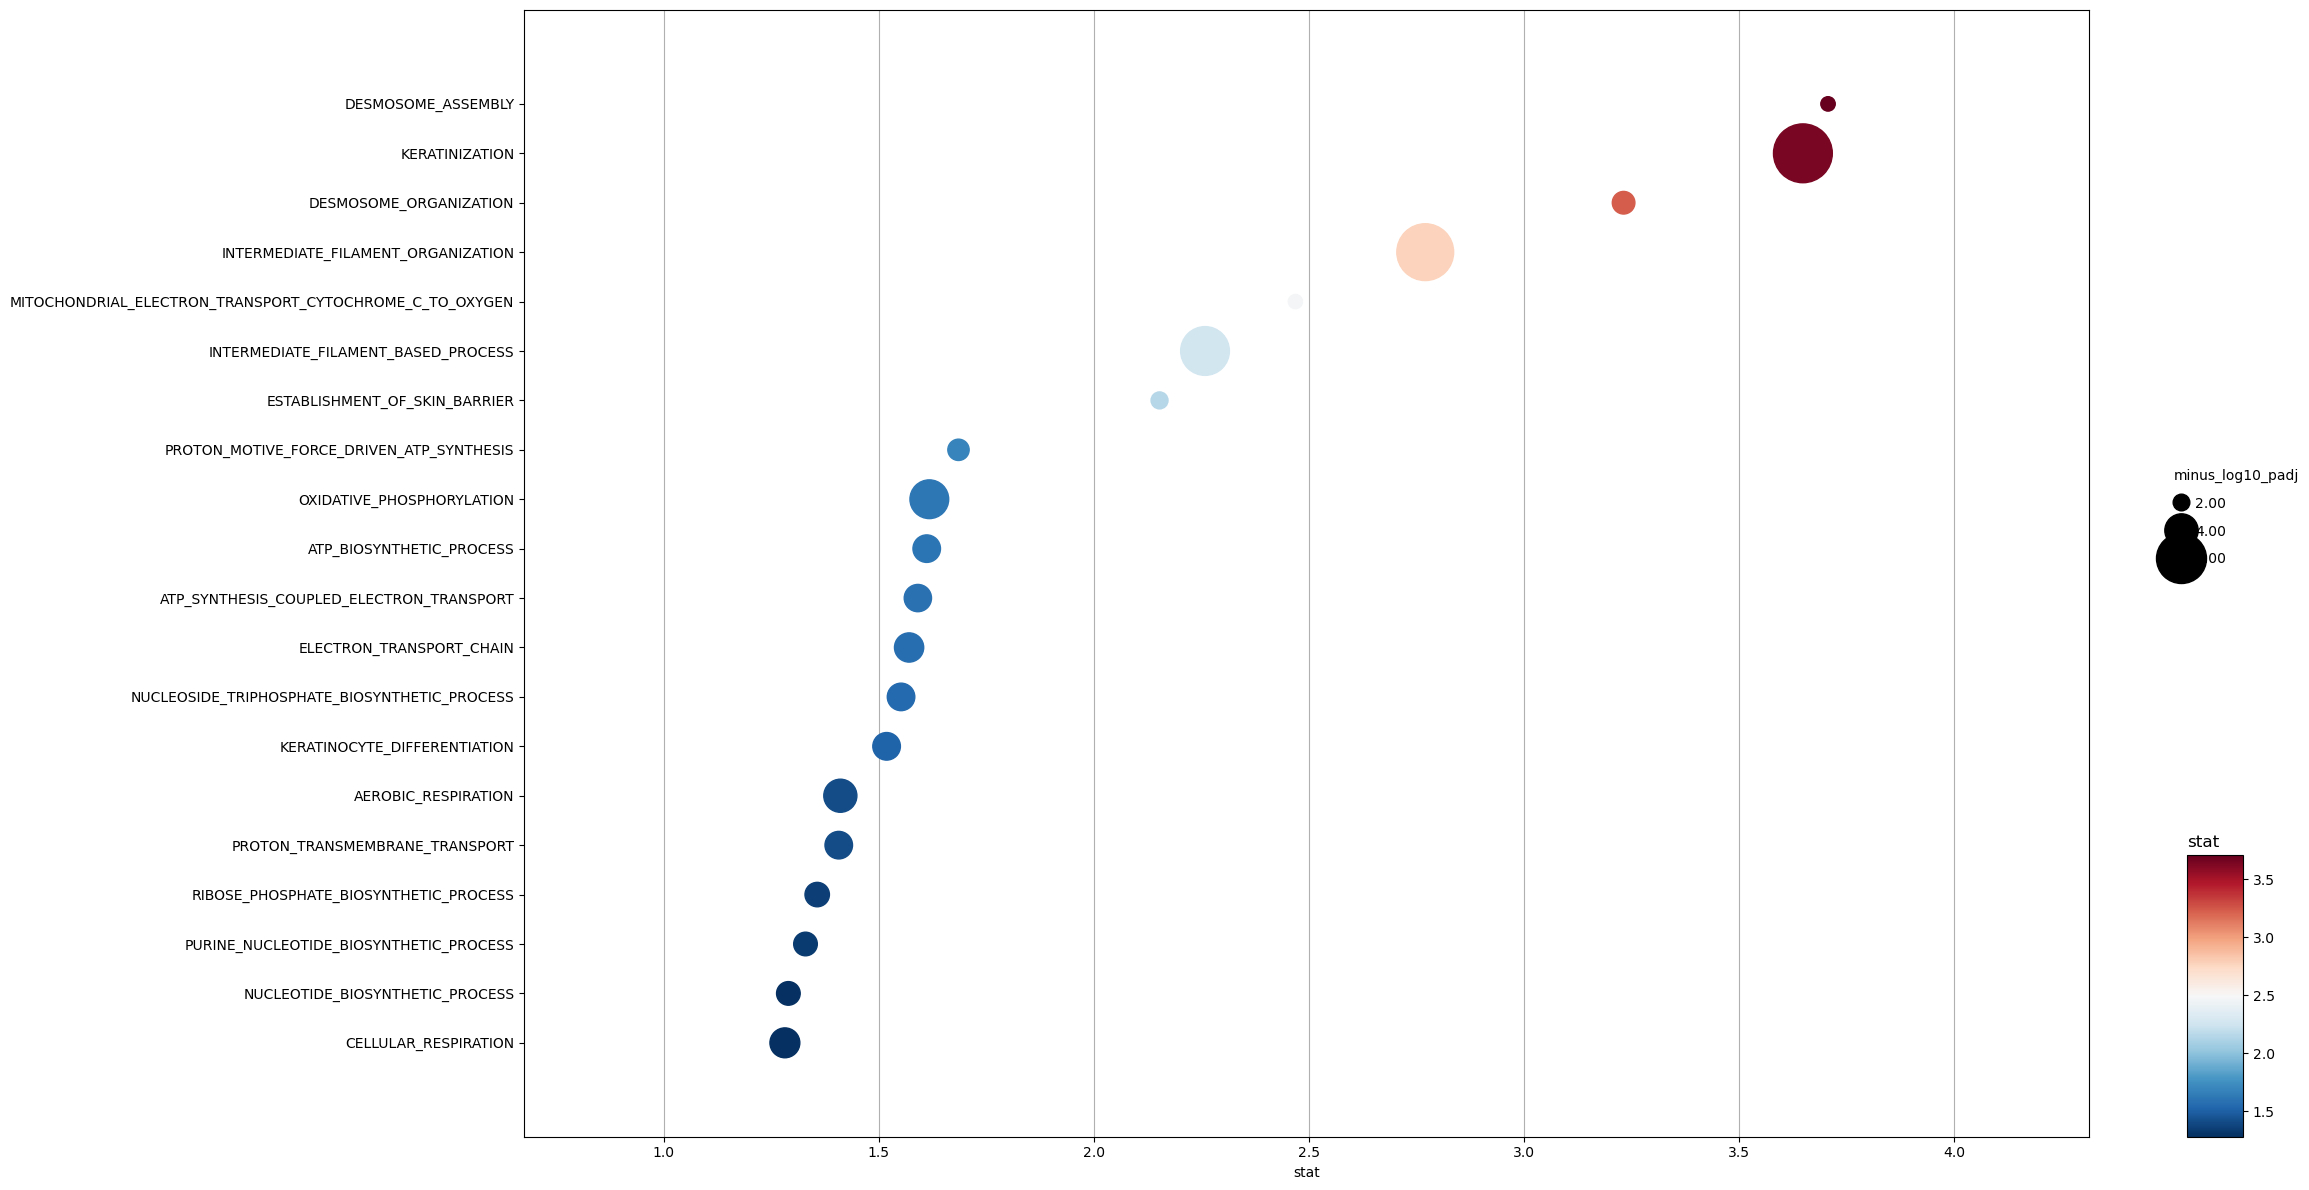

In [52]:
dc.pl.dotplot(
    df=ora_go_up_sig,
    x="stat",
    y="source",
    c="stat",
    s="minus_log10_padj",
    top=20,
    scale=1,
    figsize=(25, 12),
)

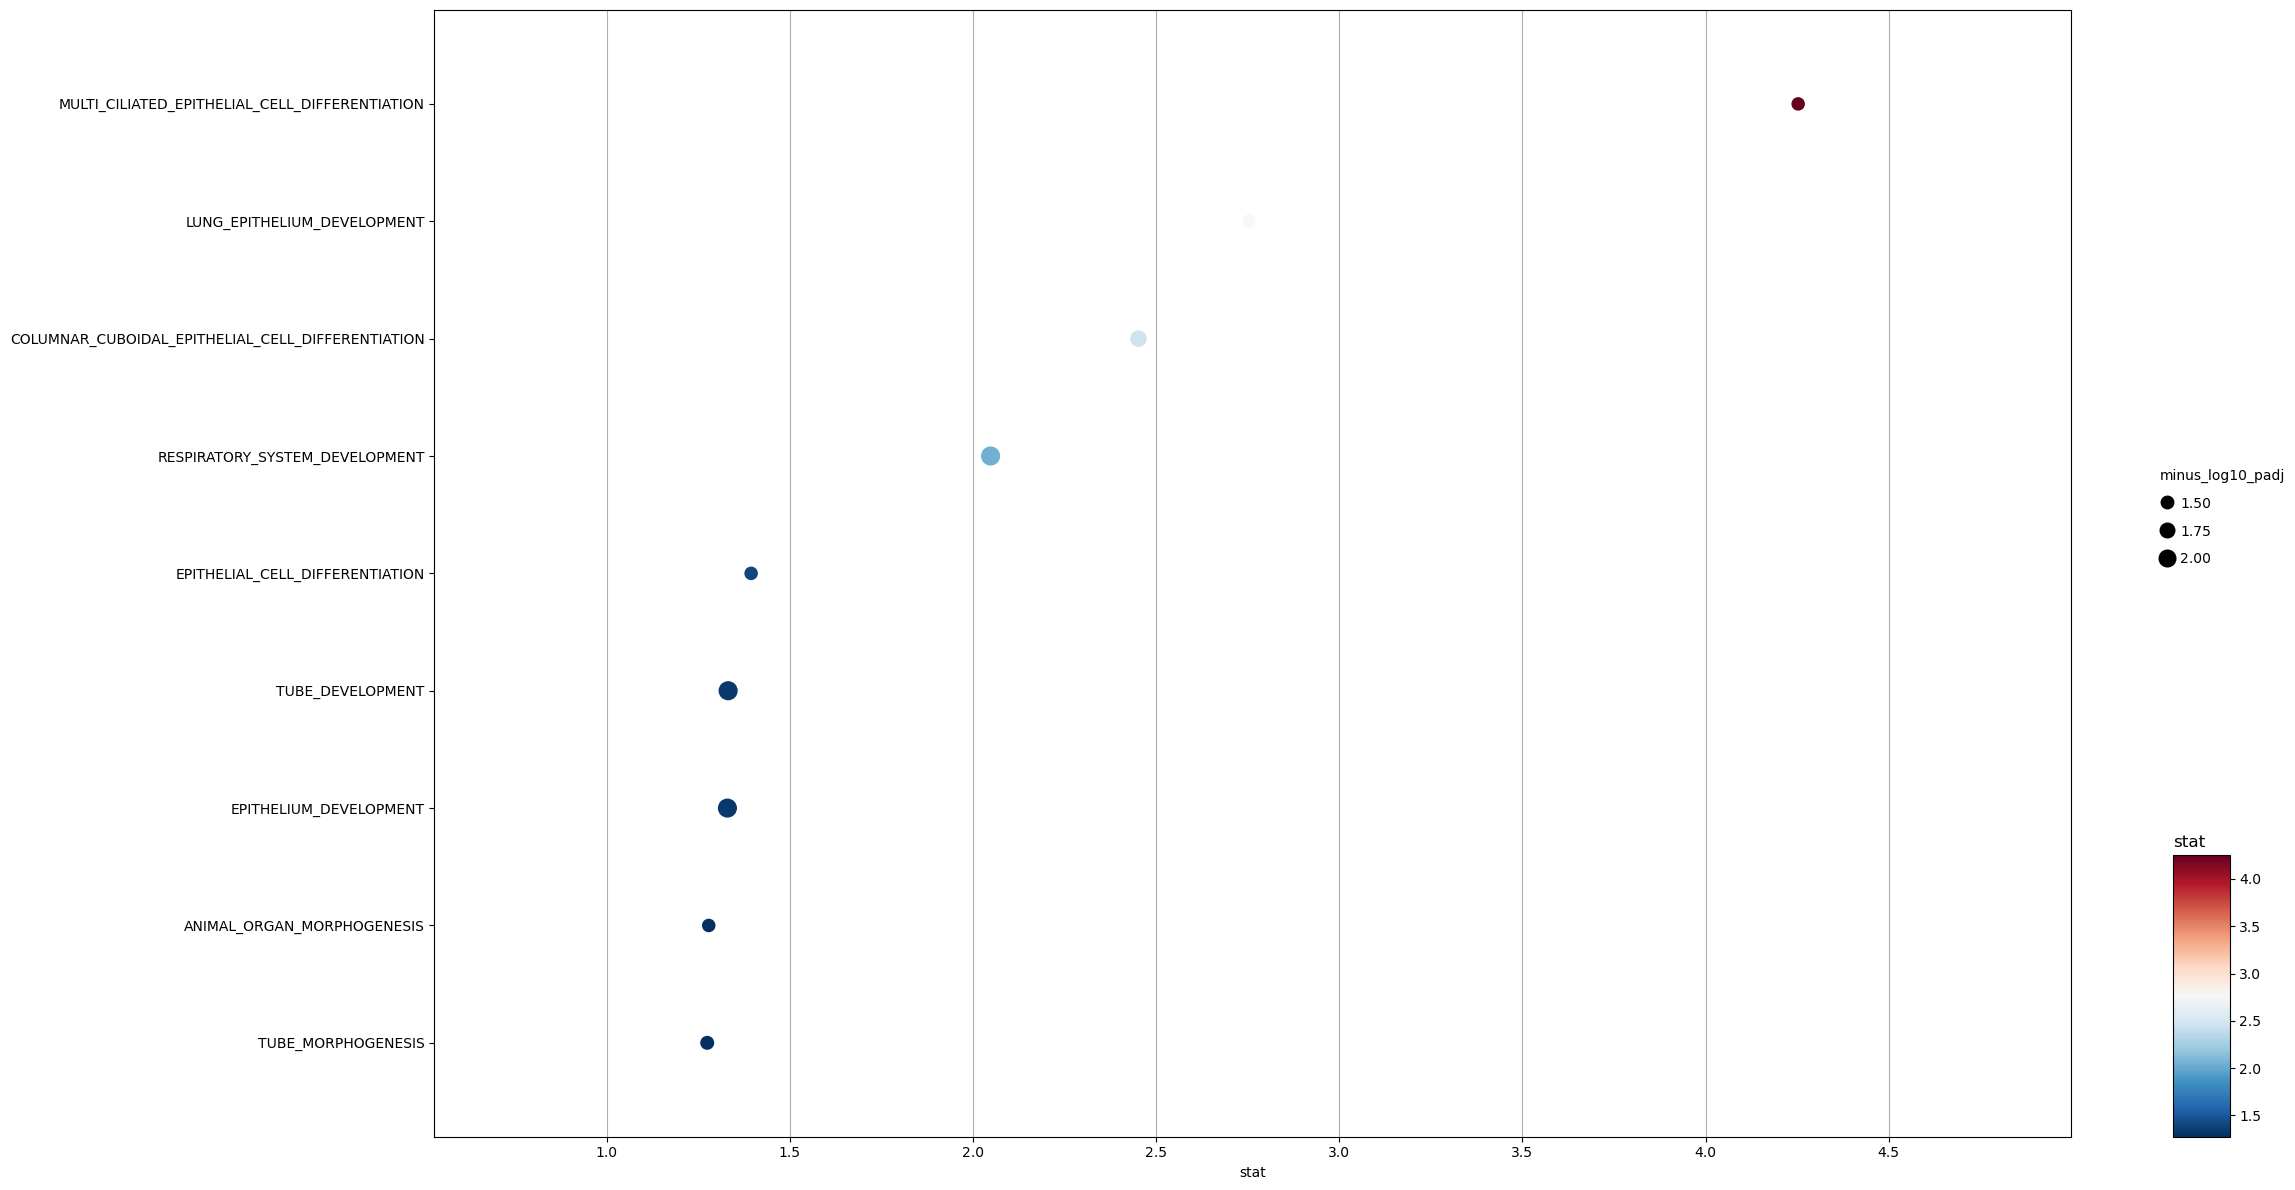

In [53]:
dc.pl.dotplot(
    df=ora_go_down_sig,
    x="stat",
    y="source",
    c="stat",
    s="minus_log10_padj",
    top=20,
    scale=1,
    figsize=(25, 12),
)